# HW3 - Cognitive Science Course
# Parsa Daghigh
#810101419


In [1]:
! pip install mne

Extracting parameters from /content/sub1_face.set...
Not setting metadata
36 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /content/sub1_dull.set...
Not setting metadata
34 matching events found
No baseline correction applied
0 projection items activated
Ready.


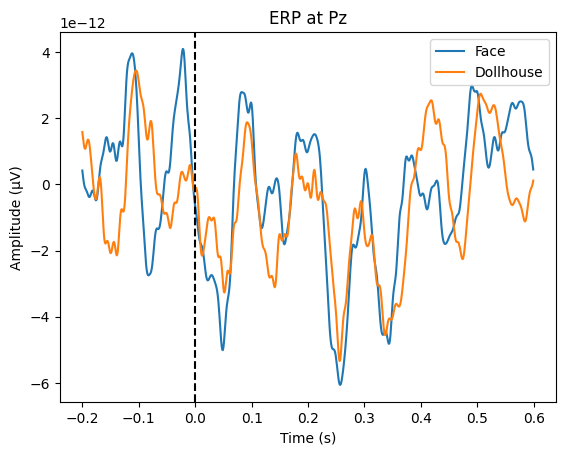

Applying baseline correction (mode: ratio)
Applying baseline correction (mode: ratio)
No baseline correction applied


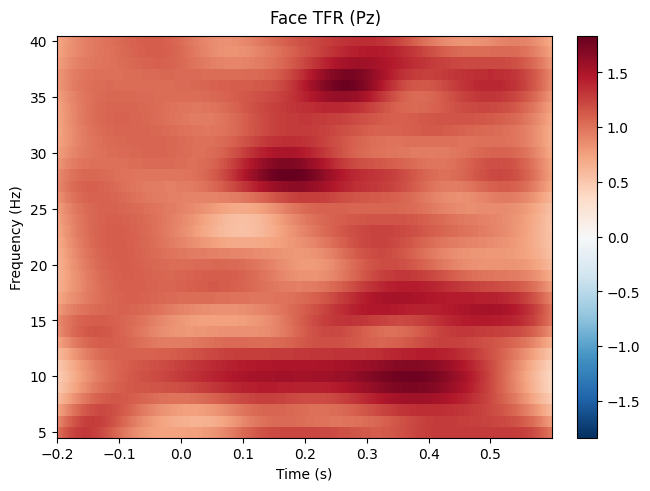

No baseline correction applied


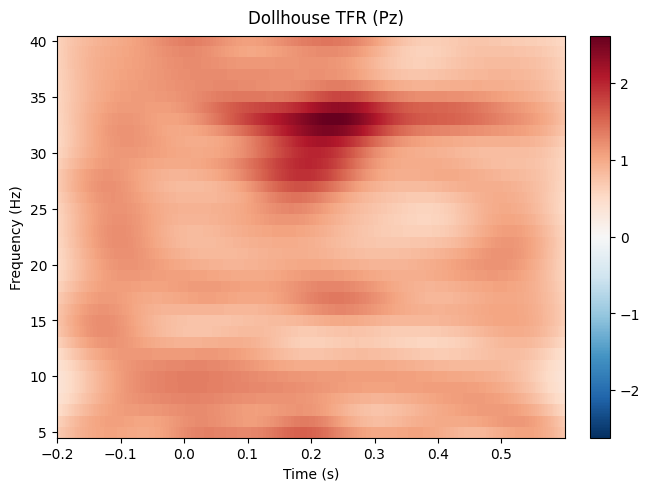

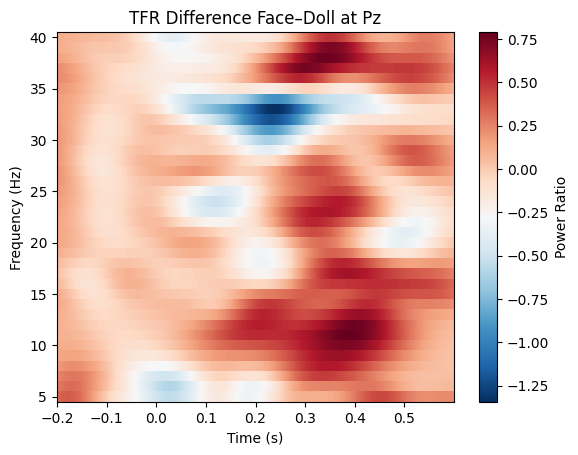

In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# === EDIT THESE PATHS TO YOUR FILE LOCATIONS ===
face_set_path = 'sub1_face.set'
doll_set_path = 'sub1_dull.set'

# === 1. Load EEGLAB epochs ===
epochs_face = mne.read_epochs_eeglab(face_set_path)
epochs_doll = mne.read_epochs_eeglab(doll_set_path)
epochs_face.load_data()
epochs_doll.load_data()

# === 2. Pool event IDs ===
face_keys = [k for k in epochs_face.event_id if k.startswith('496')]
doll_keys = [k for k in epochs_doll.event_id if k.startswith('436')]

# === 3. Compute ERPs ===
evoked_face = epochs_face[face_keys].average()
evoked_doll = epochs_doll[doll_keys].average()

# Plot ERP at Pz
chan = 'Pz'
picks = mne.pick_channels(evoked_face.info['ch_names'], include=[chan])
plt.figure()
plt.plot(evoked_face.times, evoked_face.data[picks, :].T, label='Face')
plt.plot(evoked_doll.times, evoked_doll.data[picks, :].T, label='Dollhouse')
plt.axvline(0, linestyle='--', color='k')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.legend()
plt.title(f'ERP at {chan}')
plt.show()

# === 4. Time–Frequency Analysis ===
freqs = np.arange(5., 41., 1.)      # 5–40 Hz
n_cycles = freqs / 2.               # cycles per freq (fits in 0.8 s)

power_face = epochs_face[face_keys].compute_tfr(
    method='morlet', freqs=freqs, n_cycles=n_cycles,
    return_itc=False, average=True, decim=1
)
power_doll = epochs_doll[doll_keys].compute_tfr(
    method='morlet', freqs=freqs, n_cycles=n_cycles,
    return_itc=False, average=True, decim=1
)

# === 5. Baseline Correction ===
power_face.apply_baseline(baseline=(-0.2, 0), mode='ratio')
power_doll.apply_baseline(baseline=(-0.2, 0), mode='ratio')

# === 6. Plot TFRs at Pz ===
power_face.plot(picks=[chan], baseline=None, mode='ratio',
                title=f'Face TFR ({chan})')
power_doll.plot(picks=[chan], baseline=None, mode='ratio',
                title=f'Dollhouse TFR ({chan})')

# === 7. Difference TFR ===
diff = power_face.data - power_doll.data
chan_idx = picks[0]
fig, ax = plt.subplots()
im = ax.pcolormesh(power_face.times, power_face.freqs, diff[chan_idx],
                   shading='auto', cmap='RdBu_r')
ax.set(title=f'TFR Difference Face–Doll at {chan}',
       xlabel='Time (s)', ylabel='Frequency (Hz)')
fig.colorbar(im, ax=ax, label='Power Ratio')
plt.show()


In [3]:
# Label all epochs: 1 = face, 0 = doll
X_face = epochs_face[face_keys].get_data()  # shape: (n_trials, n_channels, n_times)
X_doll = epochs_doll[doll_keys].get_data()

# Stack and label
X = np.concatenate([X_face, X_doll], axis=0)
y = np.concatenate([np.ones(len(X_face)), np.zeros(len(X_doll))])


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

win = 10  # 10-sample averaging window for temporal MVPA

n_times = X.shape[2]
scores = np.zeros(n_times)

for t in range(n_times):
    start = max(0, t - win)
    stop  = min(n_times, t + win)
    Xt = X[:, :, start:stop].mean(axis=2)
    scores[t] = cross_val_score(clf, Xt, y, cv=cv, scoring='roc_auc').mean()


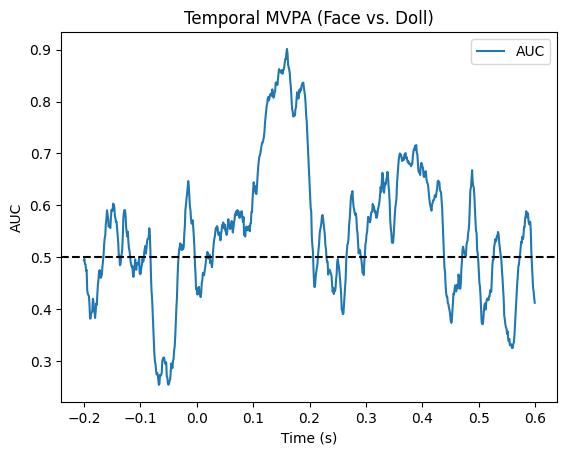

In [5]:
times = epochs_face.times
plt.figure()
plt.plot(times, scores, label='AUC')
plt.axhline(0.5, color='k', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('AUC')
plt.title('Temporal MVPA (Face vs. Doll)')
plt.legend()
plt.show()


In [6]:
# --- Select time window (e.g., 170–250 ms)
t_start, t_end = 0.170, 0.250
t_mask = (times >= t_start) & (times <= t_end)

# --- Average over that window (shape: trials × channels)
X_window = X[:, :, t_mask].mean(axis=2)

# --- Classifier with standardization
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
score = cross_val_score(clf, X_window, y, cv=cv, scoring='roc_auc').mean()

print(f"Spatial MVPA AUC (170–250 ms): {score:.3f}")


Spatial MVPA AUC (170–250 ms): 0.674


In [7]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

# === Inputs ===
# X: shape (n_trials, n_channels, n_times)
# y: labels (1=face, 0=doll), shape (n_trials,)
# times: time vector, shape (n_times,)

# === Config ===
win = 10             # ±10 sample window = 20 ms
n_perm = 200
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

n_trials, n_ch, n_times = X.shape

# === Step 1: Temporal smoothing
X_smooth = np.zeros_like(X)
for t in range(n_times):
    start = max(0, t - win)
    stop  = min(n_times, t + win)
    X_smooth[:, :, t] = X[:, :, start:stop].mean(axis=2)

# === Step 2: True AUC per time point
true_scores = np.zeros(n_times)
for t in range(n_times):
    Xt = X_smooth[:, :, t]
    true_scores[t] = cross_val_score(clf, Xt, y, cv=cv, scoring='roc_auc', n_jobs=-1).mean()

In [8]:

import mne

# 1. Concatenate your two Epochs objects
epochs_all = mne.concatenate_epochs([epochs_face, epochs_doll])


# 2. Now epochs_all.events and epochs_all.get_data() contain both face & dollhouse trials


Not setting metadata
70 matching events found
No baseline correction applied


In [9]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from collections import defaultdict

# 1) Gather epochs per image
# Assume `epochs_all` contains both face & dollhouse epochs, with event_id like '4961','4361', etc.
image_epochs = defaultdict(list)
for ev, ep in zip(epochs_all.events[:,2], epochs_all.get_data()):
    # ev is code like 4963 or 4367 → extract image ID via %10
    img_id = ev % 10  # gives 1–8 for your ID scheme
    image_epochs[img_id].append(ep)

# 2) Average per image → patterns: dict img_id → array (channels × times)
patterns = {img: np.mean(trials, axis=0) for img, trials in image_epochs.items()}

# 3) At each timepoint, build an RDM
times = epochs_all.times
n_images = len(patterns)
ids      = sorted(patterns.keys())

# Stack patterns into array (images × channels × times)
data = np.stack([patterns[i] for i in ids], axis=0)

# Preallocate RDMs: (times × images × images)
RDMs = np.zeros((len(times), n_images, n_images))

for ti in range(len(times)):
    # patterns at this time → shape (images × channels)
    X_t = data[:, :, ti]
    # compute 1 – corr
    corr = np.corrcoef(X_t)    # images×images
    RDMs[ti] = 1 - corr



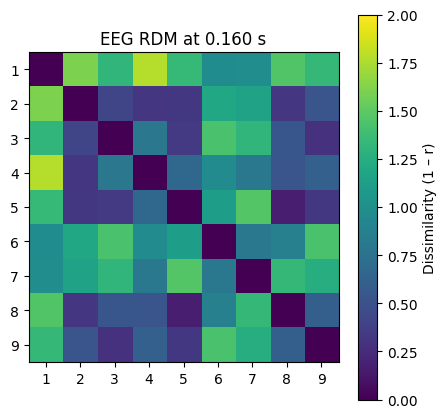

In [10]:
import matplotlib.pyplot as plt

t_idx = np.argmax(true_scores)  # time of max MVPA
plt.figure(figsize=(5,5))
plt.imshow(RDMs[t_idx], vmin=0, vmax=2, cmap='viridis')
plt.xticks(range(n_images), ids); plt.yticks(range(n_images), ids)
plt.title(f'EEG RDM at {times[t_idx]:.3f} s')
plt.colorbar(label='Dissimilarity (1 – r)')
plt.show()


In [11]:
# install directly from the official CORnet repo
! pip install git+https://github.com/dicarlolab/CORnet.git


  Cloning https://github.com/dicarlolab/CORnet.git to /tmp/pip-req-build-tizdfubx
  Running command git clone --filter=blob:none --quiet https://github.com/dicarlolab/CORnet.git /tmp/pip-req-build-tizdfubx
  Resolved https://github.com/dicarlolab/CORnet.git to commit d0cc17d4b34ad44dedb01683b70eafd15515adad
  Preparing metadata (setup.py) ... done


In [12]:
! wget https://s3.amazonaws.com/cornet-models/cornet_s-1d3f7974.pth

--2025-08-01 07:43:55--  https://s3.amazonaws.com/cornet-models/cornet_s-1d3f7974.pth
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.176.84, 54.231.235.40, 16.182.71.104, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.176.84|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 427540696 (408M) [binary/octet-stream]
Saving to: ‘cornet_s-1d3f7974.pth.1’

cornet_s-1d3f7974.p 100%[===================>] 407.73M  16.5MB/s    in 27s     

2025-08-01 07:44:23 (15.0 MB/s) - ‘cornet_s-1d3f7974.pth.1’ saved [427540696/427540696]



In [13]:
import os
import torch
import requests

# Adjust these paths/URLs
weights_url = 'https://s3.amazonaws.com/cornet-models/cornet_s-1d3f7974.pth'  # the exact URL you found
weights_path = 'cornet_s-1d3f7974.pth'  # e.g. './cornet_s.pth'

# Download if not already present
if not os.path.exists(weights_path):
    print("Downloading CORnet-S weights...")
    r = requests.get(weights_url, stream=True)
    with open(weights_url, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Download complete.")



In [1]:
import torch
print(torch.cuda.is_available())        # True if a CUDA GPU is usable
print(torch.cuda.device_count(), "GPUs:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")


True
1 GPUs: Tesla T4


In [14]:
import torch, pickle
from cornet import cornet_s
from collections import OrderedDict

# 1) Instantiate model without weights (it may be wrapped in DataParallel internally)
model = cornet_s(pretrained=False)
model.eval()

# 2) Load the raw checkpoint
ckpt = torch.load(
    weights_path,
    map_location='cpu',
    pickle_module=pickle,
    weights_only=False
)

# 3) Extract the actual state_dict
if 'state_dict' in ckpt:
    sd = ckpt['state_dict']
else:
    sd = ckpt

# 4) Inspect key formats
model_keys = list(model.state_dict().keys())
sd_keys    = list(sd.keys())

# 5) Decide whether to add or strip 'module.' prefix
if model_keys[0].startswith('module.') and not sd_keys[0].startswith('module.'):
    # model is DataParallel but sd is plain → add 'module.' to sd keys
    new_sd = OrderedDict((f"module.{k}", v) for k, v in sd.items())
elif not model_keys[0].startswith('module.') and sd_keys[0].startswith('module.'):
    # model is plain but sd has 'module.' → strip it
    new_sd = OrderedDict((k[len('module.'):], v) for k, v in sd.items())
else:
    # formats already match
    new_sd = sd

# 6) Load into model
model.load_state_dict(new_sd)
model.to('cpu')


DataParallel(
  (module): Sequential(
    (V1): Sequential(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (nonlin1): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (nonlin2): ReLU(inplace=True)
      (output): Identity()
    )
    (V2): CORblock_S(
      (conv_input): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (skip): Conv2d(128, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (norm_skip): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv2d(128, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (no

In [15]:
from google.colab import drive

In [16]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [21]:
from collections import OrderedDict

# Reconstruct image_epochs the same way you did originally:
# (if you still have the code that produced `image_epochs`, reuse it;
# otherwise assuming you have epochs_all and event codes encoding image identity)

# Example extraction logic: adjust if your image ID encoding differs
image_epochs = OrderedDict()
for ev_code, trial in zip(epochs_all.events[:, 2], epochs_all.get_data()):
    # Derive the image string used in filenames from the event code.
    # This depends on how you mapped triggers to image names.
    # If your codes were like 4961..4969 or 4361..4369, and the last digit
    # corresponds to an image number, you might do:
    if str(ev_code).startswith('496'):
        prefix = 'face_'
        num = int(str(ev_code)[-1])  # e.g., '4963' -> 3
    elif str(ev_code).startswith('436'):
        prefix = 'dollhouse_'
        num = int(str(ev_code)[-1])
    else:
        continue  # skip unexpected

    # Your naming had suffixes like 'b' or 's'; if you used e.g. '01b' for the first
    # and others '02s', etc., you need the logic that was used. For example:
    suffix = 'b' if num == 1 else 's'  # adapt if your pattern differs
    img_id = f"{prefix}{num:02d}{suffix}"

    if img_id not in image_epochs:
        image_epochs[img_id] = []
    image_epochs[img_id].append(trial)

# This is the order you used for the RDM
eeg_ids = list(image_epochs.keys())
print("Recovered eeg_ids in the order used for RDMs:")
print(eeg_ids)


Recovered eeg_ids in the order used for RDMs:
[]


In [22]:
import numpy as np
from collections import Counter

# Show event_id dictionary (what MNE parsed)
print("epochs_all.event_id keys:", epochs_all.event_id)

# Raw event codes in the data
codes = epochs_all.events[:, 2]
print("Unique event codes found:", np.unique(codes))

# Frequency of each code (to see repeats)
print("Counts per code:", Counter(codes))

# Show first 20 event codes with their corresponding epoch indices
print("First 20 event codes and indices:")
for i, ev in enumerate(codes[:20]):
    print(f"Epoch {i}: code {ev}")


epochs_all.event_id keys: {'4969': 1, '4961': 2, '4965': 3, '4962': 4, '4964': 5, '4967': 6, '4968': 7, '4963': 8, '4966': 9, '4368': 1, '4365': 2, '4363': 3, '4369': 4, '4361': 5, '4362': 6, '4364': 7, '4367': 8, '4366': 9}
Unique event codes found: [1 2 3 4 5 6 7 8 9]
Counts per code: Counter({np.int64(1): 8, np.int64(2): 8, np.int64(3): 8, np.int64(5): 8, np.int64(6): 8, np.int64(7): 8, np.int64(8): 8, np.int64(4): 7, np.int64(9): 7})
First 20 event codes and indices:
Epoch 0: code 1
Epoch 1: code 2
Epoch 2: code 3
Epoch 3: code 4
Epoch 4: code 5
Epoch 5: code 6
Epoch 6: code 5
Epoch 7: code 7
Epoch 8: code 1
Epoch 9: code 4
Epoch 10: code 7
Epoch 11: code 2
Epoch 12: code 8
Epoch 13: code 6
Epoch 14: code 9
Epoch 15: code 8
Epoch 16: code 9
Epoch 17: code 3
Epoch 18: code 5
Epoch 19: code 4


In [23]:
from collections import OrderedDict

image_epochs = OrderedDict()
for ev_code, trial in zip(epochs_all.events[:, 2], epochs_all.get_data()):
    ev_str = str(ev_code)
    if ev_str.startswith('496'):          # face
        prefix = 'face_'
    elif ev_str.startswith('436'):        # dollhouse
        prefix = 'dollhouse_'
    else:
        continue

    img_num = int(ev_str[-1])             # last digit as number
    suffix = 'b' if img_num == 1 else 's'  # adapt if your naming differs
    img_id = f"{prefix}{img_num:02d}{suffix}"

    if img_id not in image_epochs:
        image_epochs[img_id] = []
    image_epochs[img_id].append(trial)

eeg_ids = list(image_epochs.keys())
print("Recovered eeg_ids order:", eeg_ids)


Recovered eeg_ids order: []


Using EEG image IDs (in order): ['dollhouse_01b', 'dollhouse_02s', 'dollhouse_03s', 'dollhouse_04s', 'dollhouse_05s', 'dollhouse_06s', 'dollhouse_07s', 'dollhouse_08s', 'dollhouse_09s']


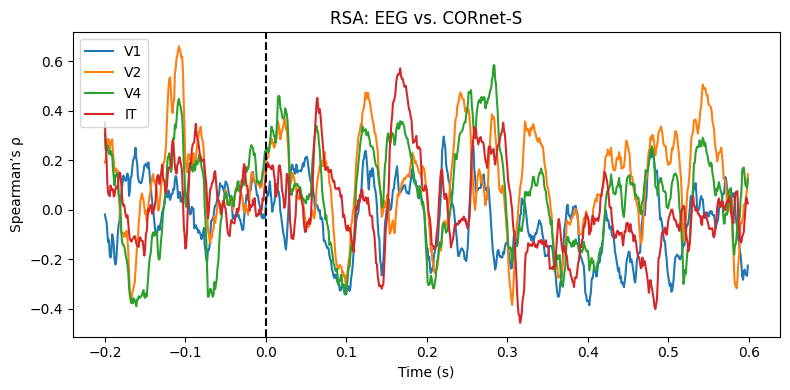

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from cornet import cornet_s
from torchvision import transforms
from PIL import Image
from scipy.stats import spearmanr

# === 0. Determine n_images from your EEG RDMs ===
# RDMs: numpy array of shape (n_times, n_images, n_images)
n_times, n_images, _ = RDMs.shape
times = times  # your time vector

# === 1. Build eeg_ids by listing sorted filenames ===
# This must match the order you used when creating RDMs!
# We assume you first used all files in the dollhouse folder, then all in the face folder.
doll_files = sorted([f for f in os.listdir(doll_dir) if f.lower().endswith(('.jpg','.png'))])
face_files = sorted([f for f in os.listdir(face_dir) if f.lower().endswith(('.jpg','.png'))])

all_files  = doll_files + face_files
if len(all_files) < n_images:
    raise ValueError(f"Found only {len(all_files)} images but RDMs has {n_images}")
all_files = all_files[:n_images]

# Extract IDs (filename without extension)
eeg_ids = [os.path.splitext(fn)[0] for fn in all_files]
print("Using EEG image IDs (in order):", eeg_ids)

# === 2. Prepare CORnet-S (unwrap DataParallel) ===
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_model = model.module if hasattr(model, 'module') else model
base_model.to(device).eval()

# === 3. Hook layers ===
features            = {}
layers_of_interest  = ['V1','V2','V4','IT']
def make_hook(name):
    def hook(module, inp, out):
        features[name] = out.detach()
    return hook

for layer in layers_of_interest:
    getattr(base_model, layer).register_forward_hook(make_hook(layer))

# === 4. Preproc transform ===
preproc = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# === 5. Extract CORnet-S features in eeg_ids order ===
model_feats = {layer: [] for layer in layers_of_interest}
for fn in all_files:
    folder = doll_dir if fn in doll_files else face_dir
    img = Image.open(os.path.join(folder, fn)).convert('RGB')
    x   = preproc(img).unsqueeze(0).to(device)
    with torch.no_grad():
        _ = base_model(x)
    for layer in layers_of_interest:
        out      = features[layer].cpu().numpy().squeeze()
        feat_vec = out.reshape(-1)
        model_feats[layer].append(feat_vec)

# Stack → (n_images × feat_dim)
for layer in layers_of_interest:
    model_feats[layer] = np.stack(model_feats[layer], axis=0)

# === 6. Compute model RDMs ===
iu = np.triu_indices(n_images, k=1)
model_RDMs = {}
for layer, data in model_feats.items():
    corr = np.corrcoef(data)
    model_RDMs[layer] = 1 - corr

# === 7. RSA over time ===
rsa_results = {layer: np.zeros(n_times) for layer in layers_of_interest}
for layer in layers_of_interest:
    mvec = model_RDMs[layer][iu]
    for t in range(n_times):
        evec = RDMs[t][iu]
        rho, _ = spearmanr(evec, mvec)
        rsa_results[layer][t] = rho

# === 8. Plot RSA ===
plt.figure(figsize=(8,4))
for layer in layers_of_interest:
    plt.plot(times, rsa_results[layer], label=layer)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('Time (s)'); plt.ylabel("Spearman’s ρ")
plt.title('RSA: EEG vs. CORnet-S')
plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
plt.figure(figsize=(10, 5))
for layer in layers_of_interest:
    plt.plot(times, rsa_results[layer], label=layer)
    sig = pvals_by_layer[layer] < 0.05
    plt.fill_between(times, 0, 1, where=sig, alpha=0.1)

plt.axhline(0, color='k', linestyle='--', linewidth=0.7)
plt.axvline(0, color='k', linestyle='--', linewidth=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Spearman’s ρ")
plt.title("RSA: EEG vs CORnet-S (shaded = p < 0.05)")
plt.legend()
plt.tight_layout()
plt.show()


In [40]:
model_RDMs

{'V1': array([[1.11022302e-16, 6.46856545e-01, 6.29007471e-01, 6.59385863e-01,
         6.54072537e-01, 6.81644226e-01, 6.59709523e-01, 6.90731480e-01,
         6.63487100e-01, 6.35034209e-01, 7.01707547e-01, 6.22449498e-01,
         6.31941364e-01, 6.26944940e-01, 7.01012104e-01, 6.18855566e-01,
         6.27551816e-01, 5.74145714e-01, 7.06703244e-01, 6.70000152e-01],
        [6.46856545e-01, 2.22044605e-16, 6.77095832e-01, 6.50526473e-01,
         6.05147541e-01, 6.66438236e-01, 6.47699247e-01, 5.86686534e-01,
         6.78478176e-01, 6.88943282e-01, 6.77094585e-01, 6.26965460e-01,
         7.44727379e-01, 6.57934922e-01, 6.15842057e-01, 6.95423366e-01,
         6.19553651e-01, 6.44616040e-01, 6.78987470e-01, 6.42401645e-01],
        [6.29007471e-01, 6.77095832e-01, 2.22044605e-16, 6.47338480e-01,
         6.79233189e-01, 6.44065596e-01, 6.90848377e-01, 6.76498682e-01,
         6.55009831e-01, 5.86744387e-01, 7.09261136e-01, 5.79642201e-01,
         6.18186002e-01, 6.44762039e-01, 7.

/tmp/ipython-input-2052209603.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


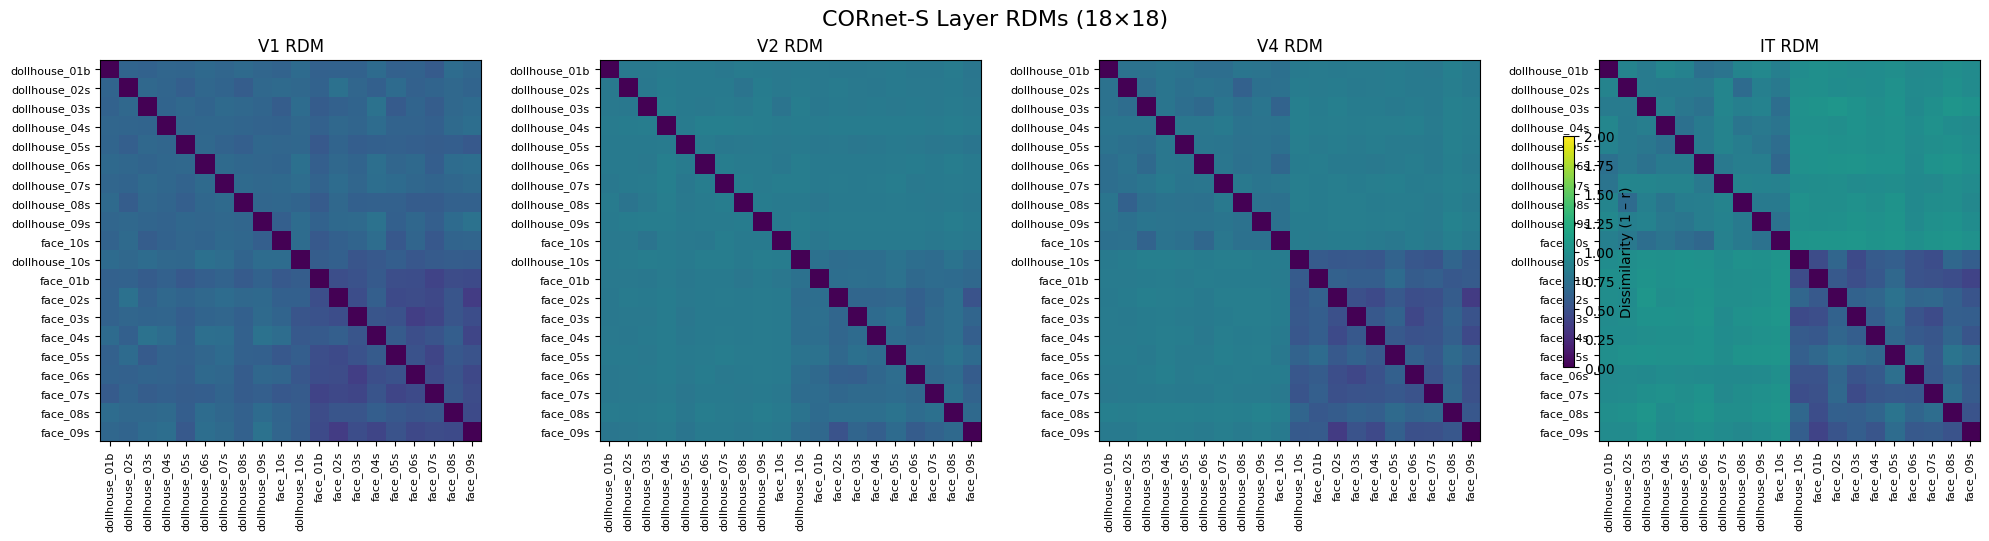

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# === Your image IDs (should be in same order as EEG/model RDMs)
# If you have 18 total images (9 face, 9 dollhouse), use:
assert len(eeg_ids) == 20, "Expected 20 image IDs"
n_images = 20

# === Plot one RDM per layer ===
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, layer in enumerate(['V1', 'V2', 'V4', 'IT']):
    ax = axs[i]
    rdm = model_RDMs[layer]

    im = ax.imshow(rdm, vmin=0, vmax=2, cmap='viridis')
    ax.set_title(f'{layer} RDM')
    ax.set_xticks(range(n_images))
    ax.set_yticks(range(n_images))
    ax.set_xticklabels(eeg_ids, rotation=90, fontsize=8)
    ax.set_yticklabels(eeg_ids, fontsize=8)

fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.6, label='Dissimilarity (1 – r)')
plt.suptitle("CORnet-S Layer RDMs (18×18)", fontsize=16)
plt.tight_layout()
plt.show()


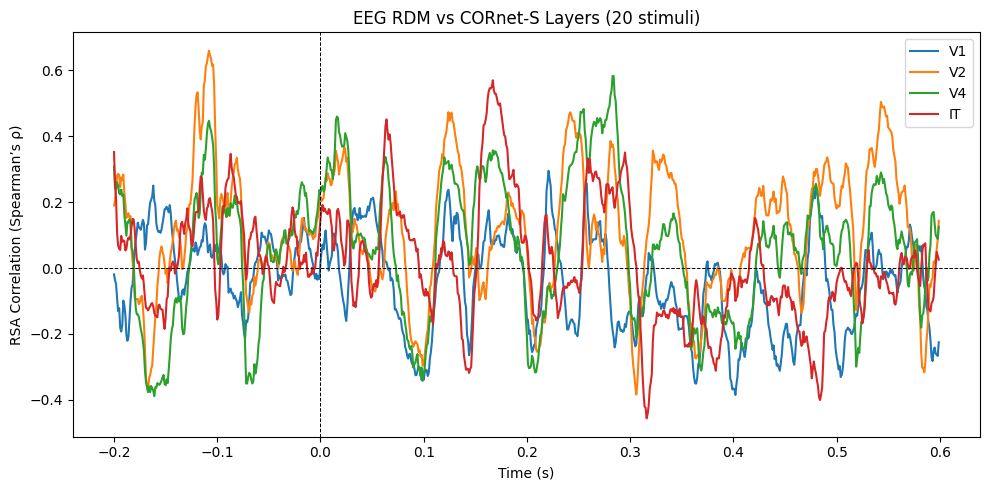

In [42]:
plt.figure(figsize=(10,5))
for layer in ['V1','V2','V4','IT']:
    plt.plot(times, rsa_results[layer], label=layer)

plt.axhline(0, color='k', linestyle='--', linewidth=0.7)
plt.axvline(0, color='k', linestyle='--', linewidth=0.7)
plt.xlabel("Time (s)")
plt.ylabel("RSA Correlation (Spearman’s ρ)")
plt.title("EEG RDM vs CORnet-S Layers (20 stimuli)")
plt.legend()
plt.tight_layout()
plt.show()
